# Агрегация результатов в один файл

In [6]:
# ============================================================================
# ИМПОРТЫ И НАСТРОЙКИ
# ============================================================================
import pandas as pd
import numpy as np
import os
from pathlib import Path

# ============================================================================
# КОНФИГУРАЦИЯ
# ============================================================================
DEGREES = range(1, 7)  # 1-6
NOISE_LEVELS = ['low', 'moderate', 'high']
BASE_PATH = '.'
OUTPUT_DIR = 'merged_entropy_results'

# ============================================================================
# ЧАСТЬ 1: ОБЪЕДИНЕНИЕ АГРЕГИРОВАННЫХ МЕТОРИК
# ============================================================================

def load_aggregated_results(base_path, degrees, noise_levels):
    """
    Загружает и объединяет все файлы polynomial_results_deg{degree}_noise_level_{noise_level}.csv
    """
    all_results = []
    
    print("=" * 95)
    print("ЧАСТЬ 1: ОБЪЕДИНЕНИЕ АГРЕГИРОВАННЫХ МЕТОРИК")
    print("=" * 95)
    
    for degree in degrees:
        for noise_level in noise_levels:
            filepath = f'{base_path}/polynomial_results_deg{degree}_noise_level_{noise_level}.csv'
            
            if os.path.exists(filepath):
                df = pd.read_csv(filepath)
                
                # Нормализуем названия столбцов
                if 'true_degree' in df.columns:
                    df.rename(columns={'true_degree': 'degree'}, inplace=True)
                
                # Добавляем метод
                df['method'] = 'entropy'
                
                # Добавляем информацию об источнике
                df['source_file'] = os.path.basename(filepath)
                
                all_results.append(df)
                print(f"✓ Загружен: {filepath} ({len(df)} строк)")
            else:
                print(f"⚠ Не найден: {filepath}")
    
    if all_results:
        combined_df = pd.concat(all_results, ignore_index=True)
        
        # Упорядочиваем столбцы
        preferred_order = ['degree', 'noise_level', 'method', 
                          'imse_mean', 'imse_sem', 
                          'imae_mean', 'imae_sem', 
                          'maxerr_mean', 'maxerr_sem',
                          'source_file']
        
        available_cols = [col for col in preferred_order if col in combined_df.columns]
        remaining_cols = [col for col in combined_df.columns if col not in preferred_order]
        
        combined_df = combined_df[available_cols + remaining_cols]
        
        return combined_df
    else:
        return pd.DataFrame()


# ============================================================================
# ЧАСТЬ 2: ОБЪЕДИНЕНИЕ ДАННЫХ ПО ДАТАСЕТАМ
# ============================================================================

def extract_true_coefficients(df_noise, degree):
    """
    Извлекает истинные коэффициенты из файла noise_*.csv для каждого seed.
    Возвращает DataFrame с одной строкой на seed.
    """
    # Находим все колонки coeff_* (исключаем coeff_scale и coeff_offset)
    coeff_cols = [col for col in df_noise.columns 
                  if col.startswith('coeff_') and col not in ['coeff_scale', 'coeff_offset']]
    
    # Сортируем по номеру коэффициента
    coeff_cols = sorted(coeff_cols, key=lambda x: int(x.split('_')[1]) if '_' in x else 0)
    
    # Оставляем только коэффициенты до степени degree (включительно)
    # Для степени degree нужно degree+1 коэффициентов: coeff_0, coeff_1, ..., coeff_degree
    coeff_cols = [col for col in coeff_cols 
                  if '_' in col and int(col.split('_')[1]) <= degree]
    
    # Группируем по seed и берём первые значения (они одинаковы для всех точек одного seed)
    group_cols = ['seed', 'degree', 'noise_level']
    available_group_cols = [col for col in group_cols if col in df_noise.columns]
    
    if not available_group_cols:
        return pd.DataFrame()
    
    # Берём первую строку для каждого seed
    df_true = df_noise.groupby(available_group_cols)[coeff_cols].first().reset_index()
    
    # Переименовываем coeff_* в true_coeff_*
    rename_dict = {col: f'true_{col}' for col in coeff_cols}
    df_true.rename(columns=rename_dict, inplace=True)
    
    return df_true


def load_params_files(base_path, degrees, noise_levels):
    """
    Загружает все файлы polynomial_params_deg{degree}_noise_level_{noise_level}.csv
    """
    all_params = []
    
    for degree in degrees:
        for noise_level in noise_levels:
            filepath = f'{base_path}/polynomial_params_deg{degree}_noise_level_{noise_level}.csv'
            
            if os.path.exists(filepath):
                df = pd.read_csv(filepath)
                
                # Нормализуем названия столбцов
                if 'true_degree' in df.columns:
                    df.rename(columns={'true_degree': 'degree'}, inplace=True)
                
                # Добавляем информацию об источнике
                df['source_file'] = os.path.basename(filepath)
                
                all_params.append(df)
                print(f"✓ Загружен: {filepath} ({len(df)} строк)")
            else:
                print(f"⚠ Не найден: {filepath}")
    
    return all_params


def load_noise_files(base_path, degrees, noise_levels):
    """
    Загружает все файлы noise_{noise_level}_deg{degree}.csv и извлекает истинные коэффициенты
    """
    all_true_coeffs = []
    
    for degree in degrees:
        for noise_level in noise_levels:
            filepath = f'{base_path}/noise_{noise_level}_deg{degree}.csv'
            
            if os.path.exists(filepath):
                df = pd.read_csv(filepath)
                df_true = extract_true_coefficients(df, degree)
                
                if len(df_true) > 0:
                    all_true_coeffs.append(df_true)
                    print(f"✓ Загружен: {filepath} ({len(df_true)} уникальных seed'ов)")
            else:
                print(f"⚠ Не найден: {filepath}")
    
    return all_true_coeffs


def combine_dataset_info(base_path, degrees, noise_levels):
    """
    Объединяет всю информацию по датасетам:
    - seed
    - noise_level
    - degree (true)
    - true_coefficients
    - selected_degree
    - selected_coefficients
    - c1, c2
    """
    print("\n" + "=" * 95)
    print("ЧАСТЬ 2: ОБЪЕДИНЕНИЕ ДАННЫХ ПО ДАТАСЕТАМ")
    print("=" * 95)
    
    # 1. Загружаем все файлы параметров
    print("\nЗагрузка файлов параметров (polynomial_params_*.csv)...")
    all_params = load_params_files(base_path, degrees, noise_levels)
    
    if not all_params:
        print("⚠ Нет файлов параметров для обработки!")
        return pd.DataFrame()
    
    # 2. Загружаем все файлы с истинными коэффициентами
    print("\nЗагрузка файлов с истинными коэффициентами (noise_*.csv)...")
    all_true_coeffs = load_noise_files(base_path, degrees, noise_levels)
    
    # 3. Объединяем все параметры в один DataFrame
    df_params_combined = pd.concat(all_params, ignore_index=True)
    print(f"\n✓ Всего параметров: {len(df_params_combined)} строк")
    
    # 4. Объединяем все истинные коэффициенты в один DataFrame
    if all_true_coeffs:
        df_true_combined = pd.concat(all_true_coeffs, ignore_index=True)
        print(f"✓ Всего истинных коэффициентов: {len(df_true_combined)} строк")
    else:
        df_true_combined = pd.DataFrame()
    
    # 5. Merge параметров с истинными коэффициентами
    merge_cols = ['seed', 'degree', 'noise_level']
    available_merge_cols = [col for col in merge_cols if col in df_params_combined.columns and col in df_true_combined.columns]
    
    if available_merge_cols and len(df_true_combined) > 0:
        df_combined = df_params_combined.merge(
            df_true_combined,
            on=available_merge_cols,
            how='left',
            suffixes=('_selected', '_true')
        )
        print(f"✓ После merge: {len(df_combined)} строк")
    else:
        df_combined = df_params_combined.copy()
        print("⚠ Merge не выполнен (нет общих ключей или истинных коэффициентов)")
    
    # 6. Форматируем итоговый DataFrame
    # Переименовываем для единообразия
    rename_map = {
        'degree': 'true_degree',
        'selected_degree': 'selected_degree',
        'coefficients': 'selected_coefficients',
        'c1': 'c1',
        'c2': 'c2'
    }
    
    for old_name, new_name in rename_map.items():
        if old_name in df_combined.columns:
            df_combined.rename(columns={old_name: new_name}, inplace=True)
    
    true_coeff_cols = [col for col in df_combined.columns if col.startswith('true_coeff_')]
    if true_coeff_cols:
        # Сортируем по номеру коэффициента
        true_coeff_cols = sorted(true_coeff_cols, key=lambda x: int(x.split('_')[-1]))
        
        # Создаём список коэффициентов, исключая NaN
        def make_coeff_list(row):
            coeffs = [row[col] for col in true_coeff_cols if pd.notna(row[col])]
            return str(coeffs)
        
        df_combined['true_coefficients'] = df_combined.apply(make_coeff_list, axis=1)
        
    # Упорядочиваем столбцы
    preferred_order = [
        'seed', 'noise_level', 'true_degree', 'true_coefficients',
        'selected_degree', 'selected_coefficients', 'c1', 'c2',
        'source_file'
    ]
    
    available_cols = [col for col in preferred_order if col in df_combined.columns]
    remaining_cols = [col for col in df_combined.columns if col not in preferred_order]
    remaining_cols = [col for col in remaining_cols if col.startswith('true_coeff_')]  # оставляем только true_coeff_*
    
    df_combined = df_combined[available_cols + remaining_cols]
    
    return df_combined


# ============================================================================
# ОСНОВНОЙ СКРИПТ
# ============================================================================

if __name__ == "__main__":
    print("=" * 95)
    print("ОБЪЕДИНЕНИЕ РЕЗУЛЬТАТОВ ЭНТРОПИЙНОГО МЕТОДА")
    print("Степени: 1-6 | Уровни шума: low, moderate, high")
    print("=" * 95)
    
    # Создаём папку для результатов
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    # ========================================================================
    # ФАЙЛ 1: АГРЕГИРОВАННЫЕ МЕТРИКИ
    # ========================================================================
    
    df_aggregated = load_aggregated_results(BASE_PATH, DEGREES, NOISE_LEVELS)
    
    if len(df_aggregated) > 0:
        # Сохранение
        output_file_1 = f'{OUTPUT_DIR}/entropy_aggregated_metrics_all.csv'
        df_aggregated.to_csv(output_file_1, index=False, encoding='utf-8-sig')
        
        print("\n" + "-" * 95)
        print("ФАЙЛ 1: АГРЕГИРОВАННЫЕ МЕТРИКИ")
        print("-" * 95)
        print(f"✓ Сохранено: {output_file_1}")
        print(f"✓ Размер: {len(df_aggregated)} строк × {len(df_aggregated.columns)} столбцов")
        print(f"\n📊 Столбцы: {list(df_aggregated.columns)}")
        print(f"\n📋 Пример данных:")
        print(df_aggregated.head(10).to_string(index=False))
    else:
        print("\n⚠ Нет агрегированных данных для сохранения!")
    
    # ========================================================================
    # ФАЙЛ 2: ДАННЫЕ ПО ДАТАСЕТАМ
    # ========================================================================
    
    df_datasets = combine_dataset_info(BASE_PATH, DEGREES, NOISE_LEVELS)
    
    if len(df_datasets) > 0:
        # Сохранение
        output_file_2 = f'{OUTPUT_DIR}/entropy_datasets_all.csv'
        df_datasets.to_csv(output_file_2, index=False, encoding='utf-8-sig')
        
        print("\n" + "-" * 95)
        print("ФАЙЛ 2: ДАННЫЕ ПО ДАТАСЕТАМ")
        print("-" * 95)
        print(f"✓ Сохранено: {output_file_2}")
        print(f"✓ Размер: {len(df_datasets)} строк × {len(df_datasets.columns)} столбцов")
        print(f"\n📊 Столбцы: {list(df_datasets.columns)}")
        print(f"\n📋 Пример данных:")
        print(df_datasets.head(10).to_string(index=False))
        
        # Статистика по выбранным степеням
        if 'selected_degree' in df_datasets.columns and 'true_degree' in df_datasets.columns:
            print("\n" + "-" * 95)
            print("СТАТИСТИКА ПО ВЫБРАННЫМ СТЕПЕНЯМ")
            print("-" * 95)
            
            stats = df_datasets.groupby(['true_degree', 'noise_level']).agg({
                'seed': 'count',
                'selected_degree': ['mean', 'std', 'min', 'max']
            }).round(4)
            stats.columns = ['count', 'selected_mean', 'selected_std', 'selected_min', 'selected_max']
            stats = stats.reset_index()
            
            print(stats.to_string(index=False))
            
            # Распределение выбранных степеней
            print("\n📈 Распределение выбранных степеней:")
            degree_dist = df_datasets['selected_degree'].value_counts().sort_index()
            for deg, count in degree_dist.items():
                pct = (count / len(df_datasets)) * 100
                print(f"  Степень {deg}: {count} раз ({pct:.1f}%)")
    else:
        print("\n⚠ Нет данных по датасетам для сохранения!")
    
    # ========================================================================
    # ИТОГОВАЯ СВОДКА
    # ========================================================================
    
    print("\n" + "=" * 95)
    print("ИТОГОВАЯ СВОДКА")
    print("=" * 95)
    print(f"\n✓ Созданные файлы в папке '{OUTPUT_DIR}':")
    
    if len(df_aggregated) > 0:
        print(f"  1. entropy_aggregated_metrics_all.csv")
        print(f"     - Агрегированные метрики (IMSE, IMAE, MaxErr)")
        print(f"     - {len(df_aggregated)} строк (degree × noise_level)")
    
    if len(df_datasets) > 0:
        print(f"  2. entropy_datasets_all.csv")
        print(f"     - Данные по каждому датасету (seed)")
        print(f"     - {len(df_datasets)} строк")
        print(f"     - Включает: seed, noise_level, true_degree, true_coefficients,")
        print(f"       selected_degree, selected_coefficients, c1, c2")
    
    print("\n✓ Обработано:")
    print(f"  - Степени полинома: {list(DEGREES)}")
    print(f"  - Уровни шума: {NOISE_LEVELS}")
    print(f"  - Всего комбинаций: {len(list(DEGREES)) * len(NOISE_LEVELS)}")
    
    print("\n" + "=" * 95)
    print("ОБРАБОТКА ЗАВЕРШЕНА")
    print("=" * 95)

ОБЪЕДИНЕНИЕ РЕЗУЛЬТАТОВ ЭНТРОПИЙНОГО МЕТОДА
Степени: 1-6 | Уровни шума: low, moderate, high
ЧАСТЬ 1: ОБЪЕДИНЕНИЕ АГРЕГИРОВАННЫХ МЕТОРИК
✓ Загружен: ./polynomial_results_deg1_noise_level_low.csv (1 строк)
✓ Загружен: ./polynomial_results_deg1_noise_level_moderate.csv (1 строк)
✓ Загружен: ./polynomial_results_deg1_noise_level_high.csv (1 строк)
✓ Загружен: ./polynomial_results_deg2_noise_level_low.csv (1 строк)
✓ Загружен: ./polynomial_results_deg2_noise_level_moderate.csv (1 строк)
✓ Загружен: ./polynomial_results_deg2_noise_level_high.csv (1 строк)
✓ Загружен: ./polynomial_results_deg3_noise_level_low.csv (1 строк)
✓ Загружен: ./polynomial_results_deg3_noise_level_moderate.csv (1 строк)
✓ Загружен: ./polynomial_results_deg3_noise_level_high.csv (1 строк)
✓ Загружен: ./polynomial_results_deg4_noise_level_low.csv (1 строк)
✓ Загружен: ./polynomial_results_deg4_noise_level_moderate.csv (1 строк)
✓ Загружен: ./polynomial_results_deg4_noise_level_high.csv (1 строк)
✓ Загружен: ./polynomial

# Оценка метрик

In [2]:
# ============================================================================
# ИМПОРТЫ И НАСТРОЙКИ
# ============================================================================
import pandas as pd
import numpy as np
import os
from scipy.integrate import quad
from scipy.optimize import minimize_scalar

# ============================================================================
# ФУНКЦИИ РАСЧЁТА МЕТРИК
# ============================================================================

def create_poly_func(coeffs):
    """Создаёт функцию полинома из списка коэффициентов."""
    def poly(x):
        return sum(c * (x ** i) for i, c in enumerate(coeffs))
    return poly

def imse(g_hat, g_true, a=0, b=1):
    """IMSE через интегрирование."""
    integrand = lambda x: (g_hat(x) - g_true(x)) ** 2
    integral, _ = quad(integrand, a, b, epsabs=1e-6, limit=200)
    return integral / (b - a)

def imae(g_hat, g_true, a=0, b=1):
    """IMAE через интегрирование."""
    integrand = lambda x: abs(g_hat(x) - g_true(x))
    integral, _ = quad(integrand, a, b, epsabs=1e-6, limit=200)
    return integral / (b - a)

def maxerr(g_hat, g_true, a=0, b=1):
    """MaxErr через оптимизацию."""
    objective = lambda x: -abs(g_hat(x) - g_true(x))
    result = minimize_scalar(objective, bounds=(a, b), method='bounded')
    if result.success:
        return -result.fun
    # Фолбэк на дискретизацию
    x_grid = np.linspace(a, b, 1000)
    return max(abs(g_hat(x) - g_true(x)) for x in x_grid)

def parse_coeffs(val):
    """Парсит коэффициенты из строки или списка."""
    if isinstance(val, str):
        # Удаляем возможные np.float64() обёртки
        val = val.replace('np.float64(', '').replace(')', '')
        # Заменяем nan на None для eval
        val = val.replace('nan', 'None')
        try:
            coeffs = eval(val)
            # Фильтруем None значения
            coeffs = [c for c in coeffs if c is not None and not (isinstance(c, float) and np.isnan(c))]
            return coeffs
        except:
            return []
    elif isinstance(val, (list, np.ndarray)):
        return [c for c in val if pd.notna(c)]
    return []

def calculate_metrics_for_row(row):
    """
    Вычисляет метрики для одной строки DataFrame.
    """
    try:
        # Парсим истинные коэффициенты
        true_coeffs = parse_coeffs(row.get('true_coefficients', []))
        if not true_coeffs:
            # Пробуем собрать из отдельных колонок true_coeff_0, true_coeff_1, ...
            true_coeffs = []
            i = 0
            while f'true_coeff_{i}' in row.index:
                val = row[f'true_coeff_{i}']
                if pd.notna(val):
                    true_coeffs.append(float(val))
                i += 1
        
        # Парсим подобранные коэффициенты
        selected_coeffs = parse_coeffs(row.get('selected_coefficients', []))
        
        if not true_coeffs or not selected_coeffs:
            return {'imse': np.nan, 'imae': np.nan, 'maxerr': np.nan, 'success': False}
        
        # Создаём функции полиномов
        g_true = create_poly_func(true_coeffs)
        g_hat = create_poly_func(selected_coeffs)
        
        # Вычисляем метрики
        imse_val = imse(g_hat, g_true)
        imae_val = imae(g_hat, g_true)
        maxerr_val = maxerr(g_hat, g_true)
        
        return {'imse': imse_val, 'imae': imae_val, 'maxerr': maxerr_val, 'success': True}
    
    except Exception as e:
        return {'imse': np.nan, 'imae': np.nan, 'maxerr': np.nan, 'success': False, 'error': str(e)}

# ============================================================================
# ОСНОВНОЙ СКРИПТ
# ============================================================================

if __name__ == "__main__":
    print("=" * 95)
    print("РАСЧЁТ МЕТРИК (IMSE, IMAE, MaxErr) ДЛЯ КАЖДОГО ДАТАСЕТА")
    print("=" * 95)
    
    # Путь к файлу с объединёнными данными
    INPUT_FILE = 'merged_entropy_results/entropy_datasets_all.csv'
    OUTPUT_FILE = 'merged_entropy_results/entropy_datasets_with_metrics.csv'
    
    # Проверяем существование входного файла
    if not os.path.exists(INPUT_FILE):
        print(f"⚠ Файл не найден: {INPUT_FILE}")
        print("Сначала запустите скрипт объединения данных.")
        exit(1)
    
    # Загружаем DataFrame
    print(f"\nЗагрузка файла: {INPUT_FILE}")
    df = pd.read_csv(INPUT_FILE)
    print(f"✓ Загружено {len(df)} строк")
    print(f"✓ Столбцы: {list(df.columns)}")
    
    # ========================================================================
    # РАСЧЁТ МЕТРИК
    # ========================================================================
    
    print("\n" + "=" * 95)
    print("ВЫЧИСЛЕНИЕ МЕТРИК ДЛЯ КАЖДОЙ СТРОКИ")
    print("=" * 95)
    
    imse_list = []
    imae_list = []
    maxerr_list = []
    success_list = []
    
    for idx, row in df.iterrows():
        if (idx + 1) % 500 == 0 or idx == len(df) - 1:
            print(f"  Обработано {idx + 1}/{len(df)} строк...")
        
        metrics = calculate_metrics_for_row(row)
        imse_list.append(metrics['imse'])
        imae_list.append(metrics['imae'])
        maxerr_list.append(metrics['maxerr'])
        success_list.append(metrics['success'])
    
    # Добавляем новые столбцы
    df['imse'] = imse_list
    df['imae'] = imae_list
    df['maxerr'] = maxerr_list
    df['metrics_success'] = success_list
    
    print(f"\n✓ Метрики рассчитаны для {sum(success_list)}/{len(df)} строк")
    
    # ========================================================================
    # СТАТИСТИКА ПО МЕТРИКАМ
    # ========================================================================
    
    print("\n" + "=" * 95)
    print("СТАТИСТИКА ПО РАССЧИТАННЫМ МЕТРИКАМ")
    print("=" * 95)
    
    print(f"\nIMSE:")
    print(f"  Mean: {df['imse'].mean():.6f}")
    print(f"  Std:  {df['imse'].std():.6f}")
    print(f"  Min:  {df['imse'].min():.6f}")
    print(f"  Max:  {df['imse'].max():.6f}")
    
    print(f"\nIMAE:")
    print(f"  Mean: {df['imae'].mean():.6f}")
    print(f"  Std:  {df['imae'].std():.6f}")
    print(f"  Min:  {df['imae'].min():.6f}")
    print(f"  Max:  {df['imae'].max():.6f}")
    
    print(f"\nMaxErr:")
    print(f"  Mean: {df['maxerr'].mean():.6f}")
    print(f"  Std:  {df['maxerr'].std():.6f}")
    print(f"  Min:  {df['maxerr'].min():.6f}")
    print(f"  Max:  {df['maxerr'].max():.6f}")
    
    # ========================================================================
    # СОХРАНЕНИЕ
    # ========================================================================
    
    print("\n" + "=" * 95)
    print("СОХРАНЕНИЕ РЕЗУЛЬТАТА")
    print("=" * 95)
    
    # Создаём папку если не существует
    os.makedirs('merged_entropy_results', exist_ok=True)
    
    # Сохраняем DataFrame
    df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')
    print(f"\n✓ Сохранено: {OUTPUT_FILE}")
    print(f"✓ Размер: {len(df)} строк × {len(df.columns)} столбцов")
    
    # Вывод примера данных
    print(f"\n📋 Пример данных (первые 5 строк):")
    preview_cols = ['seed', 'noise_level', 'true_degree', 'selected_degree', 
                    'imse', 'imae', 'maxerr', 'metrics_success']
    available_cols = [col for col in preview_cols if col in df.columns]
    print(df[available_cols].head().to_string(index=False))
    
    print("\n" + "=" * 95)
    print("ОБРАБОТКА ЗАВЕРШЕНА")
    print("=" * 95)

РАСЧЁТ МЕТРИК (IMSE, IMAE, MaxErr) ДЛЯ КАЖДОГО ДАТАСЕТА

Загрузка файла: merged_entropy_results/entropy_datasets_all.csv
✓ Загружено 5400 строк
✓ Столбцы: ['seed', 'noise_level', 'true_degree', 'true_coefficients', 'selected_degree', 'selected_coefficients', 'c1', 'c2', 'source_file', 'true_coeff_0', 'true_coeff_1', 'true_coeff_2', 'true_coeff_3', 'true_coeff_4', 'true_coeff_5', 'true_coeff_6']

ВЫЧИСЛЕНИЕ МЕТРИК ДЛЯ КАЖДОЙ СТРОКИ
  Обработано 500/5400 строк...
  Обработано 1000/5400 строк...
  Обработано 1500/5400 строк...
  Обработано 2000/5400 строк...
  Обработано 2500/5400 строк...
  Обработано 3000/5400 строк...
  Обработано 3500/5400 строк...
  Обработано 4000/5400 строк...
  Обработано 4500/5400 строк...
  Обработано 5000/5400 строк...
  Обработано 5400/5400 строк...

✓ Метрики рассчитаны для 5400/5400 строк

СТАТИСТИКА ПО РАССЧИТАННЫМ МЕТРИКАМ

IMSE:
  Mean: 0.221538
  Std:  0.592505
  Min:  0.000000
  Max:  32.458935

IMAE:
  Mean: 0.312808
  Std:  0.172879
  Min:  0.000000
 

# Агрегация метрик

In [12]:
# ============================================================================
# ИМПОРТЫ И НАСТРОЙКИ
# ============================================================================
import pandas as pd
import numpy as np
import os
from pathlib import Path

# ============================================================================
# УДАЛЕНИЕ ВЫБРОСОВ (1.5 IQR)
# ============================================================================

def remove_outliers_iqr(df, metrics=['imse', 'imae', 'maxerr']):
    """
    Удаляет выбросы по методу 1.5 IQR для указанных метрик.
    ВАЖНО: Границы считаются по исходному df, маска применяется ОДИН РАЗ.
    """
    if len(df) < 4:
        return df.copy(), 0
    
    df_clean = df.copy()
    n_removed_total = 0
    
    # Создаём единую маску для всех метрик
    global_mask = np.ones(len(df_clean), dtype=bool)
    
    for metric in metrics:
        if metric not in df_clean.columns:
            continue
        
        # Работаем с копией данных для расчёта квантилей (исключаем NaN)
        valid_data = df_clean[metric].dropna()
        
        if len(valid_data) < 4:
            continue
        
        q1 = valid_data.quantile(0.25)
        q3 = valid_data.quantile(0.75)
        iqr = q3 - q1
        
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # Создаём маску для текущей метрики
        metric_mask = (df_clean[metric] >= lower_bound) & (df_clean[metric] <= upper_bound)
        metric_mask = metric_mask.fillna(False)  # NaN считаем выбросами (удаляем)
        
        # Объединяем с общей маской (логическое И)
        global_mask = global_mask & metric_mask.values
    
    # Применяем маску один раз в конце
    n_removed_total = len(df_clean) - np.sum(global_mask)
    df_clean = df_clean[global_mask].reset_index(drop=True)
    
    return df_clean, n_removed_total


# ============================================================================
# АГРЕГАЦИЯ РЕЗУЛЬТАТОВ
# ============================================================================

def aggregate_entropy_results(df_all, remove_outliers=False):
    """
    Агрегирует результаты энтропийного метода с опциональным удалением выбросов.
    Возвращает DataFrame с агрегированными записями.
    """
    if df_all.empty:
        return pd.DataFrame()
    
    # Принудительно преобразуем все числовые столбцы в float
    numeric_cols = ['imse', 'imae', 'maxerr']
    for col in numeric_cols:
        if col in df_all.columns:
            df_all[col] = pd.to_numeric(df_all[col], errors='coerce')
            df_all[col] = df_all[col].replace([np.inf, -np.inf], np.nan)
            df_all[col] = df_all[col].astype('float64')
    
    agg_results = []
    
    # Группируем по комбинации (степень, уровень шума, метод)
    grouped = df_all.groupby(['degree', 'noise_level', 'method'])
    
    for (degree, noise_level, method), group in grouped:
        n_total = len(group)
        
        if remove_outliers:
            group_clean, n_removed = remove_outliers_iqr(group)
            n_used = len(group_clean)
            if n_used < 2:  # Недостаточно данных для агрегации
                continue
        else:
            group_clean = group.copy()
            n_used = n_total
            n_removed = 0
        
        # Расчёт статистик (NaN игнорируются автоматически в mean/std)
        imse_mean = group_clean['imse'].mean()
        imse_sem = group_clean['imse'].std() / np.sqrt(n_used) if n_used > 1 else np.nan
        imae_mean = group_clean['imae'].mean()
        imae_sem = group_clean['imae'].std() / np.sqrt(n_used) if n_used > 1 else np.nan
        maxerr_mean = group_clean['maxerr'].mean()
        maxerr_sem = group_clean['maxerr'].std() / np.sqrt(n_used) if n_used > 1 else np.nan
        
        agg_results.append({
            'degree': degree,
            'noise_level': noise_level,
            'method': method,
            'imse_mean': imse_mean,
            'imse_sem': imse_sem,
            'imae_mean': imae_mean,
            'imae_sem': imae_sem,
            'maxerr_mean': maxerr_mean,
            'maxerr_sem': maxerr_sem,
            'n_used': n_used,
            'n_total': n_total,
            'n_removed': n_removed if remove_outliers else 0
        })
    
    return pd.DataFrame(agg_results)


# ============================================================================
# СТАТИСТИКА ПО СТЕПЕНЯМ И ПАРАМЕТРАМ (ДО ОЧИСТКИ)
# ============================================================================

def calculate_degree_params_stats(df_all):
    """
    Считает статистику по подобранной и реальной степени, а также параметрам c1 и c2.
    """
    if df_all.empty:
        return pd.DataFrame(), pd.DataFrame()
    
    # Статистика по степеням
    degree_stats = df_all.groupby(['degree', 'noise_level']).agg({
        'seed': 'count',
        'selected_degree': ['mean', 'std', 'min', 'max', 'median'],
        'c1': ['mean', 'std', 'min', 'max'],
        'c2': ['mean', 'std', 'min', 'max']
    }).round(6)
    
    # Упрощаем названия столбцов
    degree_stats.columns = ['n_total', 
                            'selected_deg_mean', 'selected_deg_std', 'selected_deg_min', 
                            'selected_deg_max', 'selected_deg_median',
                            'c1_mean', 'c1_std', 'c1_min', 'c1_max',
                            'c2_mean', 'c2_std', 'c2_min', 'c2_max']
    degree_stats = degree_stats.reset_index()
    
    # Распределение выбранных степеней
    degree_dist = df_all.groupby(['degree', 'noise_level', 'selected_degree']).size().unstack(fill_value=0)
    degree_dist = degree_dist.reset_index()
    
    return degree_stats, degree_dist


# ============================================================================
# ОСНОВНОЙ СКРИПТ
# ============================================================================

if __name__ == "__main__":
    print("=" * 95)
    print("ОБРАБОТКА РЕЗУЛЬТАТОВ ЭНТРОПИЙНОГО МЕТОДА С УДАЛЕНИЕМ ВЫБРОСОВ")
    print("=" * 95)
    
    # Путь к файлу с метриками
    INPUT_FILE = 'merged_entropy_results/entropy_datasets_with_metrics.csv'
    OUTPUT_DIR = 'merged_entropy_results'
    
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    # ========================================================================
    # ЗАГРУЗКА ДАННЫХ
    # ========================================================================
    
    print("\nЗагрузка данных...")
    if not os.path.exists(INPUT_FILE):
        print(f"⚠ Файл не найден: {INPUT_FILE}")
        exit(1)
    
    df = pd.read_csv(INPUT_FILE)
    print(f"✓ Загружено {len(df)} строк")
    
    # Нормализуем названия столбцов
    if 'true_degree' in df.columns and 'degree' not in df.columns:
        df.rename(columns={'true_degree': 'degree'}, inplace=True)
    
    # Добавляем столбец method
    df['method'] = 'entropy'
    
    # ========================================================================
    # СТАТИСТИКА ДО ОЧИСТКИ
    # ========================================================================
    
    print("\n" + "=" * 95)
    print("СТАТИСТИКА ПО СТЕПЕНЯМ И ПАРАМЕТРАМ (ДО ОЧИСТКИ)")
    print("=" * 95)
    
    degree_stats, degree_dist = calculate_degree_params_stats(df)
    
    if len(degree_stats) > 0:
        print("\n📊 Статистика по степеням и параметрам:")
        print(degree_stats.to_string(index=False))
        
        # Сохранение
        degree_stats.to_csv(f'{OUTPUT_DIR}/entropy_degree_params_stats.csv', index=False)
        print(f"\n✓ Сохранено: {OUTPUT_DIR}/entropy_degree_params_stats.csv")
        
        print("\n📈 Распределение выбранных степеней:")
        print(degree_dist.to_string(index=False))
        
        degree_dist.to_csv(f'{OUTPUT_DIR}/entropy_degree_distribution.csv', index=False)
        print(f"✓ Сохранено: {OUTPUT_DIR}/entropy_degree_distribution.csv")
    
    # ========================================================================
    # АГРЕГАЦИЯ БЕЗ УДАЛЕНИЯ ВЫБРОСОВ
    # ========================================================================
    
    print("\n" + "=" * 95)
    print("АГРЕГАЦИЯ РЕЗУЛЬТАТОВ (БЕЗ УДАЛЕНИЯ ВЫБРОСОВ)")
    print("=" * 95)
    
    df_raw = aggregate_entropy_results(df.copy(), remove_outliers=False)
    
    if len(df_raw) > 0:
        print(f"\n✓ Агрегировано {len(df_raw)} записей")
        
        # Сохранение
        df_raw.to_csv(f'{OUTPUT_DIR}/entropy_aggregated_raw.csv', index=False)
        print(f"✓ Сохранено: {OUTPUT_DIR}/entropy_aggregated_raw.csv")
        
        # Вывод таблицы
        print("\n" + "-" * 95)
        print("АГРЕГИРОВАННЫЕ РЕЗУЛЬТАТЫ (БЕЗ УДАЛЕНИЯ ВЫБРОСОВ)")
        print("-" * 95)
        print(df_raw.to_string(index=False, float_format='%.6f'))
        print("-" * 95)
    else:
        print("\n⚠ Нет данных для агрегации!")
    
    # ========================================================================
    # АГРЕГАЦИЯ С УДАЛЕНИЕМ ВЫБРОСОВ
    # ========================================================================
    
    print("\n" + "=" * 95)
    print("АГРЕГАЦИЯ РЕЗУЛЬТАТОВ (С УДАЛЕНИЕМ ВЫБРОСОВ, 1.5 IQR)")
    print("=" * 95)
    
    df_clean = aggregate_entropy_results(df.copy(), remove_outliers=True)
    
    if len(df_clean) > 0:
        print(f"\n✓ Агрегировано {len(df_clean)} записей")
        
        # Сохранение
        df_clean.to_csv(f'{OUTPUT_DIR}/entropy_aggregated_clean.csv', index=False)
        print(f"✓ Сохранено: {OUTPUT_DIR}/entropy_aggregated_clean.csv")
        
        # Вывод таблицы
        print("\n" + "-" * 95)
        print("АГРЕГИРОВАННЫЕ РЕЗУЛЬТАТЫ (С УДАЛЕНИЕМ ВЫБРОСОВ)")
        print("-" * 95)
        print(df_clean.to_string(index=False, float_format='%.6f'))
        print("-" * 95)
    else:
        print("\n⚠ Нет данных для агрегации!")
    
    # ========================================================================
    # СВОДКА ПО УДАЛЁННЫМ ВЫБРОСАМ
    # ========================================================================
    
    print("\n" + "=" * 95)
    print("СВОДКА ПО УДАЛЁННЫМ ВЫБРОСАМ")
    print("=" * 95)
    
    if len(df_clean) > 0:
        for _, row in df_clean.iterrows():
            removed_pct = (row['n_removed'] / row['n_total']) * 100 if row['n_total'] > 0 else 0
            print(f"degree={row['degree']:1d} | {row['noise_level']:10s} | {row['method']:8s} | "
                  f"Удалено: {row['n_removed']:3d}/{row['n_total']:3d} ({removed_pct:5.1f}%) | "
                  f"Использовано: {row['n_used']:3d} | "
                  f"IMSE={row['imse_mean']:.4f}±{row['imse_sem']:.4f}")
    else:
        print("Нет данных для отображения сводки")
    
    print("-" * 95)
    
    # ========================================================================
    # СОХРАНЕНИЕ ДАННЫХ С ФЛАГАМИ ВЫБРОСОВ
    # ========================================================================

    print("\n" + "=" * 95)
    print("СОХРАНЕНИЕ ДАННЫХ С ФЛАГАМИ ВЫБРОСОВ")
    print("=" * 95)

    # Помечаем выбросы в исходных данных
    df_with_outlier_flag = df.copy()
    df_with_outlier_flag['is_outlier'] = False

    # Для каждой группы помечаем выбросы
    for (degree, noise_level, method), group in df.groupby(['degree', 'noise_level', 'method']):
        group_clean, n_removed = remove_outliers_iqr(group)
        
        # Находим индексы выбросов (ИСПРАВЛЕНО: конвертируем set в list)
        outlier_indices = list(set(group.index) - set(group_clean.index))
        
        if len(outlier_indices) > 0:
            df_with_outlier_flag.loc[outlier_indices, 'is_outlier'] = True

    df_with_outlier_flag.to_csv(f'{OUTPUT_DIR}/entropy_datasets_with_metrics_and_outliers.csv', index=False)
    print(f"✓ Сохранено: {OUTPUT_DIR}/entropy_datasets_with_metrics_and_outliers.csv")
    
    # ========================================================================
    # ИТОГОВАЯ СВОДКА
    # ========================================================================
    
    print("\n" + "=" * 95)
    print("ИТОГОВАЯ СВОДКА")
    print("=" * 95)
    
    print(f"\n✓ Созданные файлы в папке '{OUTPUT_DIR}':")
    print("  1. entropy_aggregated_raw.csv           - агрегация без очистки")
    print("  2. entropy_aggregated_clean.csv         - агрегация с очисткой (1.5 IQR)")
    print("  3. entropy_degree_params_stats.csv      - статистика по степеням и параметрам")
    print("  4. entropy_degree_distribution.csv      - распределение выбранных степеней")
    print("  5. entropy_datasets_with_metrics_and_outliers.csv - данные с флагами выбросов")
    
    print(f"\n✓ Структура агрегированных файлов:")
    print("  degree, noise_level, method, imse_mean, imse_sem, imae_mean, imae_sem,")
    print("  maxerr_mean, maxerr_sem, n_used, n_total, n_removed")
    
    print(f"\n✓ Обработано:")
    print(f"  - Всего записей: {len(df)}")
    if len(df_clean) > 0:
        total_removed = df_clean['n_removed'].sum()
        total_used = df_clean['n_used'].sum()
        total_all = df_clean['n_total'].sum()
        print(f"  - После очистки: {total_used} записей ({(total_removed/total_all*100):.1f}% удалено)")
    
    print("\n" + "=" * 95)
    print("ОБРАБОТКА ЗАВЕРШЕНА")
    print("=" * 95)

ОБРАБОТКА РЕЗУЛЬТАТОВ ЭНТРОПИЙНОГО МЕТОДА С УДАЛЕНИЕМ ВЫБРОСОВ

Загрузка данных...
✓ Загружено 5400 строк

СТАТИСТИКА ПО СТЕПЕНЯМ И ПАРАМЕТРАМ (ДО ОЧИСТКИ)

📊 Статистика по степеням и параметрам:
 degree noise_level  n_total  selected_deg_mean  selected_deg_std  selected_deg_min  selected_deg_max  selected_deg_median  c1_mean   c1_std  c1_min  c1_max  c2_mean   c2_std  c2_min  c2_max
      1        high      300           1.230000          0.641721                 1                 5                  1.0 0.471857 0.277742     0.0     1.0 0.528143 0.277742     0.0     1.0
      1         low      300           1.183333          0.532919                 1                 5                  1.0 0.466952 0.288084     0.0     1.0 0.533048 0.288084     0.0     1.0
      1    moderate      300           1.093333          0.362943                 1                 4                  1.0 0.464810 0.295315     0.0     1.0 0.535190 0.295315     0.0     1.0
      2        high      300           1

# Анализ подобранных параметров

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Стиль
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Загрузка данных
params_stats = pd.read_csv('./merged_entropy_results/entropy_degree_params_stats.csv')
degree_dist = pd.read_csv('./merged_entropy_results/entropy_degree_distribution.csv')

# Порядок уровней шума
noise_order = ['low', 'moderate', 'high']
params_stats['noise_level'] = pd.Categorical(params_stats['noise_level'], categories=noise_order, ordered=True)

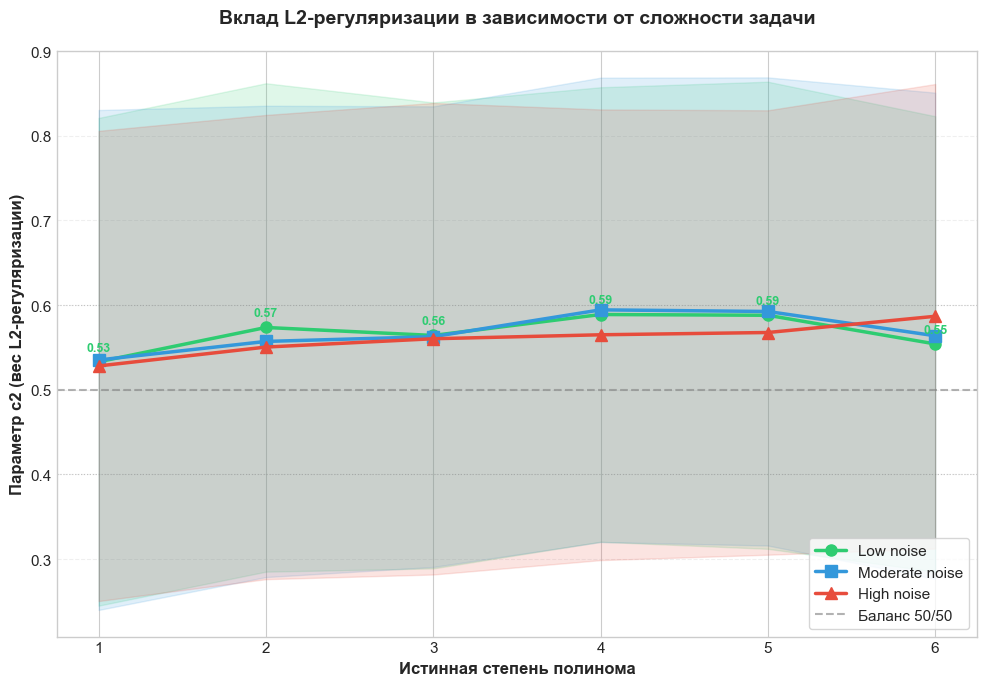

In [27]:
# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("colorblind")
plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['font.size'] = 11

fig, ax = plt.subplots(figsize=(10, 7))

colors = {'low': '#2ecc71', 'moderate': '#3498db', 'high': '#e74c3c'}
markers = {'low': 'o', 'moderate': 's', 'high': '^'}

# === Вариант: линии + точки + ЗАТЕНЁННЫЕ интервалы вместо "штрихов" ===
for noise in noise_order:
    subset = params_stats[params_stats['noise_level'] == noise].sort_values('degree')
    
    # Основная линия
    ax.plot(subset['degree'], subset['c2_mean'], 
            marker=markers[noise], linestyle='-', linewidth=2.5, 
            label=f'{noise.capitalize()} noise', color=colors[noise], markersize=8)
    
    # Затенённый интервал ±1 std (вместо громоздких errorbar)
    ax.fill_between(subset['degree'], 
                    subset['c2_mean'] - subset['c2_std'], 
                    subset['c2_mean'] + subset['c2_std'], 
                    color=colors[noise], alpha=0.15)

# Референсные линии
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='Баланс 50/50')
ax.axhline(y=0.6, color='gray', linestyle=':', linewidth=0.8, alpha=0.4)
ax.axhline(y=0.4, color='gray', linestyle=':', linewidth=0.8, alpha=0.4)

# Оформление
ax.set_xlabel('Истинная степень полинома', fontsize=12, fontweight='bold')
ax.set_ylabel('Параметр c2 (вес L2-регуляризации)', fontsize=12, fontweight='bold')
ax.set_title('Вклад L2-регуляризации в зависимости от сложности задачи', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='lower right', frameon=True, shadow=False)
# ax.set_ylim(0.35, 0.65)  # Фиксированный масштаб для наглядности малых различий
ax.set_xticks(params_stats['degree'].unique())
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Добавление аннотаций с точными значениями для low noise (как пример)
low_subset = params_stats[params_stats['noise_level'] == 'low']
for _, row in low_subset.iterrows():
    ax.annotate(f'{row["c2_mean"]:.2f}', 
                xy=(row['degree'], row['c2_mean']), 
                xytext=(0, 8), textcoords='offset points', 
                fontsize=9, ha='center', color=colors['low'], fontweight='bold')

plt.tight_layout()
plt.savefig('c2_regularization_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

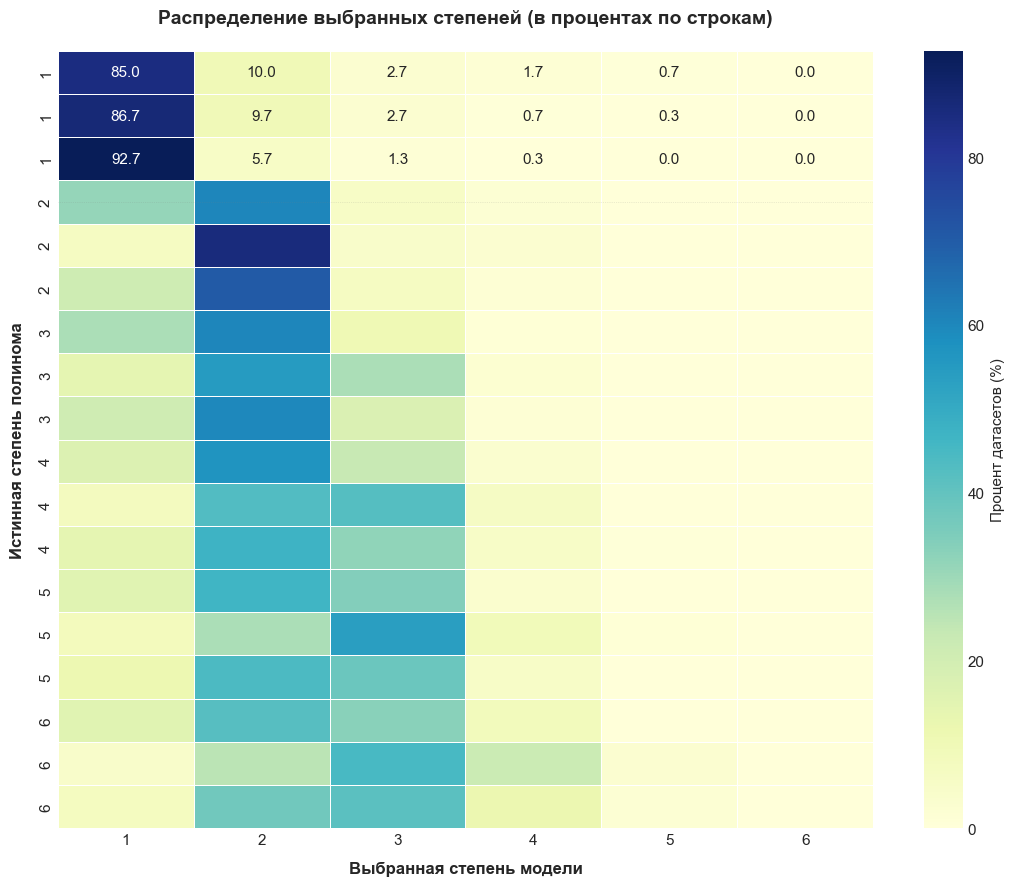

In [30]:
# Подготовка матрицы: строки — истинная степень, столбцы — выбранная
degree_matrix = degree_dist.copy()
degree_matrix_cols = degree_matrix.columns[2:].astype(int)
degree_matrix.index = degree_matrix['degree']
degree_matrix = degree_matrix.iloc[:, 2:].astype(int)
degree_matrix.columns = degree_matrix_cols

# Нормализация по строкам → проценты
degree_matrix_pct = degree_matrix.div(degree_matrix.sum(axis=1), axis=0) * 100

# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (11, 9)
plt.rcParams['font.size'] = 11

fig, ax = plt.subplots(figsize=(11, 9))

# Тепловая карта с аннотациями
sns.heatmap(degree_matrix_pct, annot=True, fmt='.1f', cmap='YlGnBu', 
            cbar_kws={'label': 'Процент датасетов (%)'}, ax=ax, 
            linewidths=0.5, linecolor='white')

# # Выделение диагонали (правильные попадания)
# for i in range(min(degree_matrix_pct.shape)):
#     ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='crimson', lw=3, zorder=10))

# Оформление осей
ax.set_xlabel('Выбранная степень модели', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Истинная степень полинома', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Распределение выбранных степеней (в процентах по строкам)', 
             fontsize=14, fontweight='bold', pad=20)

# # Добавление подписей с точностью на диагонали
# for i in range(min(degree_matrix_pct.shape)):
#     val = degree_matrix_pct.iloc[i, i]
#     ax.text(i + 0.5, i + 0.85, f'✓ {val:.1f}%', 
#             ha='center', va='top', fontsize=10, fontweight='bold', color='crimson')

# Вспомогательная линия-разделитель
ax.axhline(y=3.5, color='gray', linestyle=':', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.savefig('degree_selection_distribution_pct.png', dpi=300, bbox_inches='tight')
plt.show()